In [1]:
dataset_name = "KDD_Cup_1999"
binarize = False
random_state = 23
sample_frac = 0.10
target_column = 'label'
min_samples_per_class = 1
feature_selection_threshold = 0.99
sample_filtering_quantile = 0.10
hpo_n_trials = 10
hpo_timeout = 60
num_boost_round = 100
early_stopping_rounds = 10 # 50
plot_param_importances = False
n_jobs = -1

In [2]:
binarize_part = "Binary" if binarize else "Multiclass"
seed_part = f"seed_{random_state}"
frac_part = f"sampled_{int(100 * sample_frac):02}"
input_folder = f"../../2025-11-17/Input/{dataset_name}"
output_folder = f"../../2025-11-17/Output/{dataset_name}/{seed_part}/{frac_part}"

full_train_dataset_path = f'{input_folder}/seed_{random_state}/full/{dataset_name}_{binarize_part}_train.parquet'
full_val_dataset_path   = f'{input_folder}/seed_{random_state}/full/{dataset_name}_{binarize_part}_val.parquet'
full_test_dataset_path  = f'{input_folder}/seed_{random_state}/full/{dataset_name}_{binarize_part}_test.parquet'

sampled_train_dataset_path = f'{input_folder}/seed_{random_state}/{frac_part}/{dataset_name}_{binarize_part}_train.parquet'
sampled_val_dataset_path   = f'{input_folder}/seed_{random_state}/{frac_part}/{dataset_name}_{binarize_part}_val.parquet'
sampled_test_dataset_path  = f'{input_folder}/seed_{random_state}/{frac_part}/{dataset_name}_{binarize_part}_test.parquet'

In [3]:
# %load_ext autoreload
# %autoreload 2

from resource_monitor import ResourceMonitor

monitor = ResourceMonitor(interval=0.1)
monitor.start()

In [4]:
from optuna.exceptions import ExperimentalWarning
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=ExperimentalWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [5]:
monitor.checkpoint("reference")

[Monitor] Checkpoint 'reference' (0.19s).


# Step 1: Data Preprocessing

In [6]:
import cudf
import cupy as cp
import numpy as np
import pandas as pd
import random
import time

random.seed(random_state)
cp.random.seed(random_state)
np.random.seed(random_state)

global_start = time.time()

# Step 1: read full dataset from parquet file
df_train_full = cudf.read_parquet(full_train_dataset_path)
df_val_full   = cudf.read_parquet(full_val_dataset_path)
df_test_full  = cudf.read_parquet(full_test_dataset_path)

In [7]:
monitor.checkpoint("step_1a_data_reading")

[Monitor] Checkpoint 'step_1a_data_reading' (1.83s).


In [8]:
df_train_full

,COUNT,DIFF_SRV_RATE,DST_BYTES,DST_HOST_COUNT,DST_HOST_DIFF_SRV_RATE,DST_HOST_RERROR_RATE,DST_HOST_SAME_SRC_PORT_RATE,DST_HOST_SAME_SRV_RATE,DST_HOST_SERROR_RATE,DST_HOST_SRV_COUNT,...,SERVICE,SRC_BYTES,SRV_COUNT,SRV_DIFF_HOST_RATE,SRV_RERROR_RATE,SRV_SERROR_RATE,SU_ATTEMPTED,URGENT,WRONG_FRAGMENT,label
0,9,0.00,5938,255,0.00,0.0,0.00,1.00,0.0,255,...,http,325,9,0.00,0.0,0.0,0,0,0,normal
1,194,0.06,0,255,0.07,0.0,0.00,0.06,1.0,16,...,netbios_dgm,0,16,0.00,0.0,1.0,0,0,0,neptune
2,1,0.00,334,71,0.07,0.0,0.01,0.66,0.0,146,...,smtp,1357,1,0.00,0.0,0.0,0,0,0,normal
3,18,0.00,412,255,0.00,0.0,0.00,1.00,0.0,255,...,http,281,22,0.18,0.0,0.0,0,0,0,normal
4,78,0.09,0,255,0.07,1.0,0.00,0.01,0.0,3,...,private,0,3,0.00,1.0,0.0,0,0,0,neptune
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644993,274,0.06,0,255,0.07,0.0,0.00,0.02,1.0,4,...,private,0,14,0.00,0.0,1.0,0,0,0,neptune
644994,1,0.00,1368,37,0.05,0.0,0.03,0.97,0.0,155,...,smtp,12832,1,0.00,0.0,0.0,0,0,0,normal
644995,1,0.00,328,179,0.02,0.0,0.01,0.68,0.0,182,...,smtp,2397,2,1.00,0.0,0.0,0,0,0,normal
644996,177,0.06,0,255,0.05,0.0,0.00,0.09,1.0,24,...,private,0,24,0.00,0.0,1.0,0,0,0,neptune


In [9]:
col_info = {str(col): {} for col in df_train_full.columns}

df_train_full.shape

(644998, 41)

In [10]:
# Step 2: update columns info
for col in df_train_full.columns:
    col_info[str(col)].update({
        'nunique_1': df_train_full[col].nunique(), 
        'dtype_1': df_train_full[col].dtype, 
        'mem_1': df_train_full[col].memory_usage() / 1024**2
    })

df_train_full.shape

(644998, 41)

In [11]:
# Step 3: drop object columns if specified
object_cols = df_train_full.drop(columns=[target_column]).select_dtypes(include='object').columns

print(object_cols)

for col in df_train_full.columns:
    col_info[str(col)].update({'nunique_2': df_train_full[col].nunique(), 'dtype_2': df_train_full[col].dtype, 'mem_2': df_train_full[col].memory_usage() / 1024**2})

df_train_full.shape

Index(['FLAG', 'PROTOCOL_TYPE', 'SERVICE'], dtype='object')


(644998, 41)

In [12]:
import os
import json
from pathlib import Path

metadata_path = os.path.join(Path(full_train_dataset_path).parent, "metadata.json")

with open(metadata_path, 'r', encoding='utf-8') as f:
    metadata = json.load(f)

# Step 4: restore dtypes for other columns from metadata
for col, dtype in metadata["dtypes"].items():
    if col in df_train_full.columns:# and col not in object_cols:
        df_train_full[col] = df_train_full[col].astype(dtype)
        df_val_full[col] = df_val_full[col].astype(dtype)
        df_test_full[col] = df_test_full[col].astype(dtype)

for col in df_train_full.columns:
    col_info[str(col)].update({'nunique_3': df_train_full[col].nunique(), 'dtype_3': df_train_full[col].dtype, 'mem_3': df_train_full[col].memory_usage() / 1024**2})

In [13]:
pd.DataFrame.from_dict(col_info).T

,nunique_1,dtype_1,mem_1,nunique_2,dtype_2,mem_2,nunique_3,dtype_3,mem_3
COUNT,512,int32,2.460472,512,int32,2.460472,512,int32,2.460472
DIFF_SRV_RATE,91,float32,2.460472,91,float32,2.460472,91,float32,2.460472
DST_BYTES,19146,int32,2.460472,19146,int32,2.460472,19146,int32,2.460472
DST_HOST_COUNT,256,int32,2.460472,256,int32,2.460472,256,int32,2.460472
DST_HOST_DIFF_SRV_RATE,101,float32,2.460472,101,float32,2.460472,101,float32,2.460472
DST_HOST_RERROR_RATE,101,float32,2.460472,101,float32,2.460472,101,float32,2.460472
DST_HOST_SAME_SRC_PORT_RATE,101,float32,2.460472,101,float32,2.460472,101,float32,2.460472
DST_HOST_SAME_SRV_RATE,101,float32,2.460472,101,float32,2.460472,101,float32,2.460472
DST_HOST_SERROR_RATE,101,float32,2.460472,101,float32,2.460472,101,float32,2.460472
DST_HOST_SRV_COUNT,256,int32,2.460472,256,int32,2.460472,256,int32,2.460472


In [14]:
df_train_full.head(10)

,COUNT,DIFF_SRV_RATE,DST_BYTES,DST_HOST_COUNT,DST_HOST_DIFF_SRV_RATE,DST_HOST_RERROR_RATE,DST_HOST_SAME_SRC_PORT_RATE,DST_HOST_SAME_SRV_RATE,DST_HOST_SERROR_RATE,DST_HOST_SRV_COUNT,...,SERVICE,SRC_BYTES,SRV_COUNT,SRV_DIFF_HOST_RATE,SRV_RERROR_RATE,SRV_SERROR_RATE,SU_ATTEMPTED,URGENT,WRONG_FRAGMENT,label
0,9,0.00,5938,255,0.00,0.0,0.00,1.00,0.0,255,...,http,325,9,0.00,0.0,0.0,0,0,0,normal
1,194,0.06,0,255,0.07,0.0,0.00,0.06,1.0,16,...,netbios_dgm,0,16,0.00,0.0,1.0,0,0,0,neptune
2,1,0.00,334,71,0.07,0.0,0.01,0.66,0.0,146,...,smtp,1357,1,0.00,0.0,0.0,0,0,0,normal
3,18,0.00,412,255,0.00,0.0,0.00,1.00,0.0,255,...,http,281,22,0.18,0.0,0.0,0,0,0,normal
4,78,0.09,0,255,0.07,1.0,0.00,0.01,0.0,3,...,private,0,3,0.00,1.0,0.0,0,0,0,neptune
5,8,0.00,663,38,0.00,0.0,0.03,1.00,0.0,255,...,http,327,9,0.22,0.0,0.0,0,0,0,normal
6,14,0.00,1112,255,0.00,0.0,0.00,1.00,0.0,255,...,http,228,14,0.00,0.0,0.0,0,0,0,normal
7,11,0.00,3675,255,0.00,0.0,0.00,1.00,0.0,255,...,http,235,11,0.00,0.0,0.0,0,0,0,normal
8,1,0.00,19983,255,0.00,0.0,0.00,1.00,0.0,255,...,http,163,22,0.09,0.0,0.0,0,0,0,normal
9,20,0.00,13029,20,0.00,0.0,0.05,1.00,0.0,255,...,http,284,20,0.00,0.0,0.0,0,0,0,normal


In [15]:
df_train_full[target_column].value_counts()

label
normal             487688
neptune            145289
satan                3011
ipsweep              2234
portsweep            2138
smurf                1804
nmap                  932
back                  581
teardrop              551
warezclient           536
pod                   124
guess_passwd           32
buffer_overflow        18
warezmaster            12
land                   11
imap                    7
loadmodule              6
rootkit                 6
ftp_write               5
multihop                4
phf                     4
perl                    3
spy                     2
Name: count, dtype: int64

In [16]:
# Factorize target column
df_train_full[target_column], unique_values = df_train_full[target_column].factorize()
assert df_train_full[target_column].nunique() >= 2, "Classification requires two or more classes."
label_to_index = {value: i for i, value in enumerate(unique_values.to_pandas())}
index_to_label = {v: k for k, v in label_to_index.items()}
labels = list(label_to_index.keys())
df_train_full[target_column] = df_train_full[target_column].astype('int8')
df_val_full[target_column]  = df_val_full[target_column].map(label_to_index)
df_test_full[target_column] = df_test_full[target_column].map(label_to_index)

In [17]:
train_cols = set(df_train_full.columns.tolist())
val_cols   = set(df_val_full.columns.tolist())
test_cols  = set(df_test_full.columns.tolist())

assert train_cols == val_cols,  f"Column mismatch (train vs val): {train_cols ^ val_cols}"
assert train_cols == test_cols, f"Column mismatch (train vs test): {train_cols ^ test_cols}"

train_labels = set(df_train_full[target_column].unique().to_pandas())
val_labels   = set(df_val_full[target_column].unique().to_pandas())
test_labels  = set(df_test_full[target_column].unique().to_pandas())

# Ensure Val/Test don't contain "Surprise" classes unknown to Train
assert val_labels.issubset(train_labels), f"Validation contains unknown labels: {val_labels - train_labels}"
assert test_labels.issubset(train_labels), f"Test contains unknown labels: {test_labels - train_labels}"
print("Label consistency check passed (Val/Test are valid subsets of Train).")

Label consistency check passed (Val/Test are valid subsets of Train).


In [18]:
# Detect and assign codes to categorical columns
numeric_columns = df_train_full.drop(columns=[target_column]).select_dtypes(include=['number']).columns.tolist()
categorical_cols = df_train_full.drop(columns=[target_column]).select_dtypes(include=['category']).columns.tolist()

df_train_full[target_column].value_counts()

label
0     487688
1     145289
4       3011
3       2234
2       2138
7       1804
10       932
13       581
9        551
6        536
8        124
12        32
16        18
14        12
11        11
20         7
17         6
18         6
19         5
5          4
15         4
22         3
21         2
Name: count, dtype: int64

In [19]:
# Fill missing categorical values
def fill_categorical_nas(dfs):
    return
    for df in dfs:
        for col in df.select_dtypes(include=['category']).columns:
            if df[col].to_pandas().isna().sum() > 0:
                df[col] = cudf.Series(df[col].to_pandas().astype(str).replace("nan", "missing").astype("category"))

In [20]:
# Convert back to X, y format
X_train_full, y_train_full = df_train_full.drop(columns=[target_column]), df_train_full[target_column]
X_val_full, y_val_full = df_val_full.drop(columns=[target_column]), df_val_full[target_column]
X_test_full, y_test_full = df_test_full.drop(columns=[target_column]), df_test_full[target_column]

fill_categorical_nas([X_train_full, X_val_full, X_test_full])

In [21]:
monitor.checkpoint("step_1b_data_preprocessing")

[Monitor] Checkpoint 'step_1b_data_preprocessing' (1.06s).


# Step 2: Model and Metrics

In [22]:
import tempfile
import xgboost as xgb

from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score,
    matthews_corrcoef, cohen_kappa_score,
    log_loss, roc_auc_score, confusion_matrix
)

num_classes = df_train_full[target_column].nunique()
loss_function = 'binary:logistic' if num_classes == 2 else 'multi:softprob'
eval_metric = 'logloss' if num_classes == 2 else 'mlogloss'
n_folds, shuffle, stratify = 5, True, True

def evaluate_multiclass_metrics(
    y_true,
    y_pred,
    y_prob=None,
    labels=None,
    label_names=None
):
    metrics = {}

    metrics["accuracy"] = accuracy_score(y_true, y_pred)
    metrics["balanced_accuracy"] = balanced_accuracy_score(y_true, y_pred)
    metrics["mcc"] = matthews_corrcoef(y_true, y_pred)
    metrics["cohen_kappa"] = cohen_kappa_score(y_true, y_pred)

    for avg in ["micro", "macro", "weighted"]:
        metrics[f"precision_{avg}"] = precision_score(y_true, y_pred, average=avg, zero_division=0)
        metrics[f"recall_{avg}"] = recall_score(y_true, y_pred, average=avg, zero_division=0)
        metrics[f"f1_{avg}"] = f1_score(y_true, y_pred, average=avg, zero_division=0)

    if y_prob is not None:
        try:
            metrics["log_loss"] = log_loss(y_true, y_prob, labels=labels)
        except:
            metrics["log_loss"] = np.nan

    if y_prob is not None and labels is not None and len(np.unique(y_true)) > 1:
        for avg in ["micro", "macro", "weighted"]:
            try:
                metrics[f"roc_auc_ovr_{avg}"] = roc_auc_score(y_true, y_prob, multi_class="ovr", average=avg, labels=labels)
                metrics[f"roc_auc_ovo_{avg}"] = roc_auc_score(y_true, y_prob, multi_class="ovo", average=avg, labels=labels)
            except:
                metrics[f"roc_auc_ovr_{avg}"] = np.nan
                metrics[f"roc_auc_ovo_{avg}"] = np.nan

    if labels is None:
        labels = np.unique(y_true)
    conf = confusion_matrix(y_true, y_pred, labels=labels)
    display_labels = label_names if label_names is not None else labels
    conf_df = pd.DataFrame(conf, index=[f"True_{l}" for l in display_labels],
                                 columns=[f"Pred_{l}" for l in display_labels])

    return metrics, conf_df

def f1_weighted_eval(preds, dtrain):
    y_true = dtrain.get_label()
    weights = dtrain.get_weight()
    # Convert probabilities to class labels
    if num_classes > 2:
        y_pred = np.argmax(preds.reshape(y_true.shape[0], -1), axis=1)
    else:
        y_pred = (preds > 0.5).astype(int)
    # Use weights if provided
    if weights is not None and len(weights) > 0:
        f1 = f1_score(y_true, y_pred, average="weighted", sample_weight=weights)
    else:
        f1 = f1_score(y_true, y_pred, average="weighted")
    return "f1_weighted", f1

def get_model_size(model):
    with tempfile.NamedTemporaryFile(delete=False, suffix=".ubj") as temp_model:
        model_path = temp_model.name
    model.save_model(model_path)
    model_size_mb = os.path.getsize(model_path) / (1024 * 1024)
    os.remove(model_path)
    return round(model_size_mb, 2)

# Default XGB Booster parameters
default_booster_params = {
    "objective": loss_function,                     # Multi-class classification
    "early_stopping_rounds": early_stopping_rounds, # Number of iterations
    "num_boost_round": num_boost_round,             # Number of CV folds
    "eval_metric": eval_metric,                     # Log loss
    "device": 'cuda'                                # GPU (CUDA)
}
if num_classes > 2:
    default_booster_params["num_class"] = num_classes # Only for multi-class classification

# Default XGB CV parameters
default_cv_params = {
    "params": default_booster_params,               # Booster parameters
    "early_stopping_rounds": early_stopping_rounds, # Number of rounds before early stopping
    "num_boost_round": num_boost_round,             # Number of iterations
    "nfold": n_folds,                               # Number of CV folds
    "shuffle": shuffle,                             # Shuffle samples before creating folds
    "stratified": stratify,                         # Stratify classes on CV split
    "metrics": eval_metric,                         # Log loss
    "feval": f1_weighted_eval,                      # Monitor weighted F1 score
    "seed": random_state                            # Passed to numpy.random.seed
}

# Default XGB training parameters
default_train_params = {
    "early_stopping_rounds": early_stopping_rounds, # Number of rounds before early stopping
    "num_boost_round": num_boost_round,             # Number of iterations
}

# Function to Train, Validate, and Test XGBoost Model
def train_xgb(
    X_train, X_val, X_test, y_train, y_val, y_test,
    sample_weights=None,
    cv=False,
    custom_booster_params=None,
    metrics_filename: str = None,
    cm_filename: str = None,
    model_filename: str = None,
    verbose=1
):
    # Warmup verification
    assert sample_weights is None or len(sample_weights) == len(y_train), "Sample weights must align with training labels"

    # Create DMatrix with feature names
    dtrain = xgb.DMatrix(X_train, label=y_train, enable_categorical=True, feature_names=X_train.columns.tolist(), weight=sample_weights)
    dval = xgb.DMatrix(X_val, label=y_val, enable_categorical=True, feature_names=X_val.columns.tolist()) if X_val is not None else None
    dtest = xgb.DMatrix(X_test, label=y_test, enable_categorical=True, feature_names=X_test.columns.tolist()) if X_test is not None else None

    # Merge default booster params with custom ones
    booster_params = {**default_booster_params, **(custom_booster_params or {})}

    if cv:
        cv_params = {
            **default_cv_params,
            "params": booster_params,
            "verbose_eval": verbose
        }
        training_start = time.time()
        results = xgb.cv(dtrain=dtrain, **cv_params)
        training_end = time.time()
        training_time = (training_end - training_start) / n_folds
        latency = training_time / len(y_train)
        f1_score_ans = float(results['test-f1_weighted-mean'].mean())
        model, model_size = None, None

        # Persist the model properly
        if metrics_filename:
            os.makedirs(os.path.dirname(metrics_filename), exist_ok=True)
            results.to_csv(metrics_filename, index=True)

    else:
        training_start = time.time()
        model = xgb.train(
            params=booster_params,
            dtrain=dtrain,
            evals=[(dtrain, "Train"), (dval, "Validation")],
            **default_train_params
        )
        training_end = time.time()
        training_time = training_end - training_start

        # Predict
        test_start = time.time()
        y_pred_probs = model.predict(dtest)
        y_pred = np.argmax(y_pred_probs, axis=1) if num_classes > 2 else (y_pred_probs > 0.5).astype(int)
        test_end = time.time()
        test_time = test_end - test_start

        latency = test_time / len(y_test)

        model_size = get_model_size(model)

        metrics_dict, confusion_df = evaluate_multiclass_metrics(
            y_true=y_test.to_numpy(),
            y_pred=y_pred,
            y_prob=y_pred_probs,
            labels=list(index_to_label.keys()),
            label_names=[index_to_label[i] for i in index_to_label]
        )
        metrics_dict.update({
            'training_time': training_time, 'test_time': test_time, 'latency': latency, 'model_size': model_size
        })
        
        f1_score_ans = metrics_dict['f1_weighted']

        # Persist the results properly
        if metrics_filename:
            os.makedirs(os.path.dirname(metrics_filename), exist_ok=True)
            with open(metrics_filename, "w", encoding="utf-8") as f:
                json.dump(metrics_dict, f, indent=2)
        if cm_filename:
            os.makedirs(os.path.dirname(cm_filename), exist_ok=True)
            confusion_df.to_csv(cm_filename, index=True)
        if model_filename:
            os.makedirs(os.path.dirname(model_filename), exist_ok=True)
            model.save_model(model_filename)

    return model, training_time, latency, f1_score_ans, model_size

In [23]:
monitor.checkpoint("step_2a_train_xgb_full_definitions")

[Monitor] Checkpoint 'step_2a_train_xgb_full_definitions' (0.28s).


In [24]:
train_xgb(X_train_full, None, None, y_train_full, None, None, cv=True)

[0]	train-mlogloss:0.47336+0.00003	train-f1_weighted:0.99869+0.00001	test-mlogloss:0.47364+0.00019	test-f1_weighted:0.99862+0.00001
[1]	train-mlogloss:0.34317+0.00006	train-f1_weighted:0.99888+0.00025	test-mlogloss:0.34349+0.00014	test-f1_weighted:0.99880+0.00022
[2]	train-mlogloss:0.25101+0.00004	train-f1_weighted:0.99941+0.00002	test-mlogloss:0.25136+0.00022	test-f1_weighted:0.99935+0.00004
[3]	train-mlogloss:0.18461+0.00002	train-f1_weighted:0.99945+0.00002	test-mlogloss:0.18498+0.00020	test-f1_weighted:0.99938+0.00003
[4]	train-mlogloss:0.13630+0.00002	train-f1_weighted:0.99950+0.00001	test-mlogloss:0.13669+0.00019	test-f1_weighted:0.99942+0.00004
[5]	train-mlogloss:0.10090+0.00001	train-f1_weighted:0.99959+0.00002	test-mlogloss:0.10130+0.00017	test-f1_weighted:0.99949+0.00005
[6]	train-mlogloss:0.07483+0.00001	train-f1_weighted:0.99963+0.00001	test-mlogloss:0.07526+0.00016	test-f1_weighted:0.99953+0.00004
[7]	train-mlogloss:0.05562+0.00001	train-f1_weighted:0.99966+0.00001	test-ml

(None, 3.4700088500976562, 5.379875364106022e-06, 0.9986188, None)

In [25]:
monitor.checkpoint("step_2b_train_xgb_full_evaluation_with_cv")

[Monitor] Checkpoint 'step_2b_train_xgb_full_evaluation_with_cv' (17.53s).


In [26]:
train_xgb(X_train_full, X_val_full, X_test_full, y_train_full, y_val_full, y_test_full, cv=False)

[0]	Train-mlogloss:0.47310	Validation-mlogloss:0.69339
[1]	Train-mlogloss:0.34299	Validation-mlogloss:0.66830
[2]	Train-mlogloss:0.25082	Validation-mlogloss:0.63802
[3]	Train-mlogloss:0.18449	Validation-mlogloss:0.65543
[4]	Train-mlogloss:0.13619	Validation-mlogloss:0.63943
[5]	Train-mlogloss:0.10082	Validation-mlogloss:0.61627
[6]	Train-mlogloss:0.07478	Validation-mlogloss:0.61096
[7]	Train-mlogloss:0.05556	Validation-mlogloss:0.57174
[8]	Train-mlogloss:0.04136	Validation-mlogloss:0.49784
[9]	Train-mlogloss:0.03084	Validation-mlogloss:0.53979
[10]	Train-mlogloss:0.02303	Validation-mlogloss:0.47907
[11]	Train-mlogloss:0.01721	Validation-mlogloss:0.47057
[12]	Train-mlogloss:0.01291	Validation-mlogloss:0.47442
[13]	Train-mlogloss:0.00970	Validation-mlogloss:0.47761
[14]	Train-mlogloss:0.00733	Validation-mlogloss:0.42136
[15]	Train-mlogloss:0.00554	Validation-mlogloss:0.37609
[16]	Train-mlogloss:0.00420	Validation-mlogloss:0.35594
[17]	Train-mlogloss:0.00320	Validation-mlogloss:0.34079
[1

(<xgboost.core.Booster at 0x71d9597faa50>,
 10.396753787994385,
 3.9679282522113047e-07,
 0.9956700823317943,
 1.9)

In [27]:
monitor.checkpoint("step_2c_train_xgb_full_evaluation_without_cv")

[Monitor] Checkpoint 'step_2c_train_xgb_full_evaluation_without_cv' (15.22s).


# Step 3: Baseline Evaluation (full dataset)

In [28]:
# Train and evaluate using train_xgb function
model_full, train_time_full, latency_full, f1_weighted_full, model_size_full = train_xgb(
    X_train_full, X_val_full, X_test_full,
    y_train_full, y_val_full, y_test_full,
    cv=False,  # Cross-validation only used during HPO
    metrics_filename=f"{output_folder}/xgb_full_metrics.json",
    cm_filename=f"{output_folder}/xgb_full_cm.csv",
    model_filename=f"{output_folder}/xgb_full_model.json"
)

# Print results
print(f"Training Time (full): {train_time_full:.3f} seconds")
print(f"Latency (full): {latency_full:.2e} seconds")
print(f"Weighted F1-Score (full): {f1_weighted_full:.6f}")
print(f"Model Size: {model_size_full} MB")

[0]	Train-mlogloss:0.47310	Validation-mlogloss:0.69339
[1]	Train-mlogloss:0.34299	Validation-mlogloss:0.66830
[2]	Train-mlogloss:0.25082	Validation-mlogloss:0.63802
[3]	Train-mlogloss:0.18449	Validation-mlogloss:0.65543
[4]	Train-mlogloss:0.13619	Validation-mlogloss:0.63943
[5]	Train-mlogloss:0.10082	Validation-mlogloss:0.61627
[6]	Train-mlogloss:0.07478	Validation-mlogloss:0.61096
[7]	Train-mlogloss:0.05556	Validation-mlogloss:0.57174
[8]	Train-mlogloss:0.04136	Validation-mlogloss:0.49784
[9]	Train-mlogloss:0.03084	Validation-mlogloss:0.53979
[10]	Train-mlogloss:0.02303	Validation-mlogloss:0.47907
[11]	Train-mlogloss:0.01721	Validation-mlogloss:0.47057
[12]	Train-mlogloss:0.01291	Validation-mlogloss:0.47442
[13]	Train-mlogloss:0.00970	Validation-mlogloss:0.47761
[14]	Train-mlogloss:0.00733	Validation-mlogloss:0.42136
[15]	Train-mlogloss:0.00554	Validation-mlogloss:0.37609
[16]	Train-mlogloss:0.00420	Validation-mlogloss:0.35594
[17]	Train-mlogloss:0.00320	Validation-mlogloss:0.34079
[1

In [29]:
monitor.checkpoint("step_3_full_evaluation")

[Monitor] Checkpoint 'step_3_full_evaluation' (14.75s).


# Step 4: Updated Evaluation (with Sampling)

In [30]:
# Read sampled dataset from parquet file
df_train_sampled = cudf.read_parquet(sampled_train_dataset_path)
df_val_sampled   = cudf.read_parquet(sampled_val_dataset_path)
df_test_sampled  = cudf.read_parquet(sampled_test_dataset_path)

metadata_path = os.path.join(Path(sampled_train_dataset_path).parent, "metadata.json")

with open(metadata_path, 'r', encoding='utf-8') as f:
    metadata = json.load(f)

# Restore dtypes for other columns from metadata
for col, dtype in metadata["dtypes"].items():
    if col in df_train_sampled.columns:# and col not in object_cols:
        df_train_sampled[col] = df_train_sampled[col].astype(dtype)
        df_val_sampled[col] = df_val_sampled[col].astype(dtype)
        df_test_sampled[col] = df_test_sampled[col].astype(dtype)

df_train_sampled[target_column] = df_train_sampled[target_column].map(label_to_index)
df_val_sampled[target_column]  = df_val_sampled[target_column].map(label_to_index)
df_test_sampled[target_column] = df_test_sampled[target_column].map(label_to_index)

# Convert back to X, y format
X_train_sampled, y_train_sampled = df_train_sampled.drop(columns=[target_column]), df_train_sampled[target_column]
X_val_sampled, y_val_sampled = df_val_sampled.drop(columns=[target_column]), df_val_sampled[target_column]
X_test_sampled, y_test_sampled = df_test_sampled.drop(columns=[target_column]), df_test_sampled[target_column]

fill_categorical_nas([X_train_sampled, X_val_sampled, X_test_sampled])

In [31]:
monitor.checkpoint("step_4a_sampled_preparation")

[Monitor] Checkpoint 'step_4a_sampled_preparation' (0.5s).


In [32]:
# Train and evaluate using train_xgb function
model_sampled, train_time_sampled, latency_sampled, f1_weighted_sampled, model_size_sampled = train_xgb(
    X_train_sampled, X_val_sampled, X_test_sampled,
    y_train_sampled, y_val_sampled, y_test_sampled,
    cv=False,  # Cross-validation only used during HPO
    metrics_filename=f"{output_folder}/xgb_sampled_metrics.json",
    cm_filename=f"{output_folder}/xgb_sampled_cm.csv",
    model_filename=f"{output_folder}/xgb_sampled_model.json"
)

# Print results
print(f"Training Time (sampled): {train_time_sampled:.3f} seconds")
print(f"Latency (sampled): {latency_sampled:.2e} seconds")
print(f"Weighted F1-Score (sampled): {f1_weighted_sampled:.6f}")
print(f"Model Size: {model_size_sampled} MB")

[0]	Train-mlogloss:0.48211	Validation-mlogloss:0.70865
[1]	Train-mlogloss:0.34986	Validation-mlogloss:0.68645
[2]	Train-mlogloss:0.25646	Validation-mlogloss:0.61304
[3]	Train-mlogloss:0.18909	Validation-mlogloss:0.62668
[4]	Train-mlogloss:0.14006	Validation-mlogloss:0.56839
[5]	Train-mlogloss:0.10396	Validation-mlogloss:0.55215
[6]	Train-mlogloss:0.07739	Validation-mlogloss:0.53906
[7]	Train-mlogloss:0.05775	Validation-mlogloss:0.46801
[8]	Train-mlogloss:0.04320	Validation-mlogloss:0.40409
[9]	Train-mlogloss:0.03249	Validation-mlogloss:0.35536
[10]	Train-mlogloss:0.02450	Validation-mlogloss:0.30994
[11]	Train-mlogloss:0.01852	Validation-mlogloss:0.27970
[12]	Train-mlogloss:0.01406	Validation-mlogloss:0.26256
[13]	Train-mlogloss:0.01073	Validation-mlogloss:0.25682
[14]	Train-mlogloss:0.00821	Validation-mlogloss:0.23962
[15]	Train-mlogloss:0.00632	Validation-mlogloss:0.22227
[16]	Train-mlogloss:0.00492	Validation-mlogloss:0.20810
[17]	Train-mlogloss:0.00386	Validation-mlogloss:0.19187
[1

In [33]:
monitor.checkpoint("step_4b_sampled_evaluation")

[Monitor] Checkpoint 'step_4b_sampled_evaluation' (10.68s).


# Step 5: Updated Evaluation (with Sampling and Feature Selection)

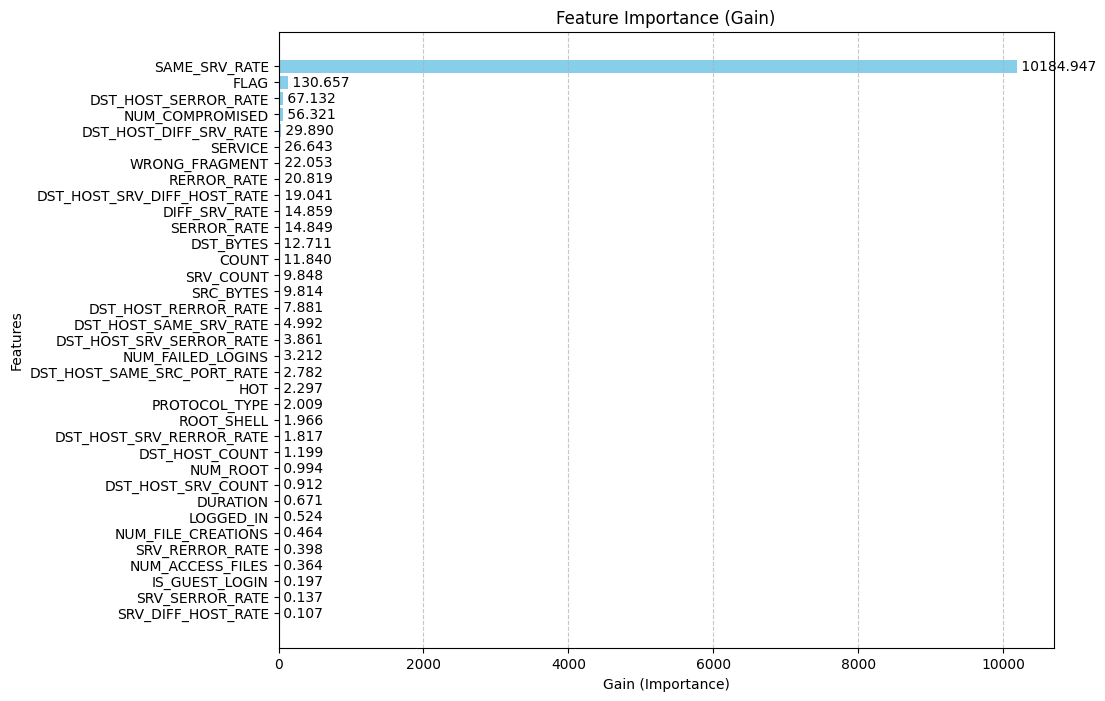

In [34]:
import matplotlib.pyplot as plt

# Calculate and sort features by importance
feature_importance = model_sampled.get_score(importance_type="gain")
sorted_features = sorted(feature_importance.items(), key=lambda x: x[1], reverse=True)
features, importance = zip(*sorted_features)

# Create the plot
plt.figure(figsize=(10, 8))
bars = plt.barh(features, importance, color='skyblue')

# Annotate each bar with its importance value
for bar, value in zip(bars, importance):
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f" {value:.3f}", va='center')

# Labels and title
plt.xlabel("Gain (Importance)")
plt.ylabel("Features")
plt.title("Feature Importance (Gain)")
plt.gca().invert_yaxis()  # Invert y-axis for better readability
plt.grid(axis='x', linestyle='--', alpha=0.7)  # Add grid for better readability

plt.savefig(f"{output_folder}/xgb_feature_importance_gain.pdf", bbox_inches="tight", dpi=300)
plt.show()

In [35]:
# Get feature importance
feature_importance = model_sampled.get_score(importance_type="gain")
importance_df = cudf.DataFrame(list(feature_importance.items()), columns=["Feature", "Importance"])
importance_df = importance_df.sort_values(by="Importance", ascending=False)

# Normalize importance scores
importance_df["Cumulative_Importance"] = importance_df["Importance"].cumsum() / importance_df["Importance"].sum()

# Find the smallest set of features that explains at least 95% of the importance
N = np.argmax(importance_df["Cumulative_Importance"] >= feature_selection_threshold) + 1  # Adjust threshold as needed

# Select top features
selected_features = importance_df["Feature"][:N].to_pandas().tolist()

print(f"Optimal number of features: {N} (from {len(feature_importance)})")

importance_df.to_csv(f"{output_folder}/xgb_feature_importance_gain.csv", index=False)
importance_df

Optimal number of features: 10 (from 35)


,Feature,Importance,Cumulative_Importance
26,SAME_SRV_RATE,10184.947266,0.954701
14,FLAG,130.656860,0.966948
8,DST_HOST_SERROR_RATE,67.132187,0.973241
19,NUM_COMPROMISED,56.320923,0.978520
4,DST_HOST_DIFF_SRV_RATE,29.889870,0.981322
28,SERVICE,26.643322,0.983820
34,WRONG_FRAGMENT,22.053474,0.985887
24,RERROR_RATE,20.819250,0.987838
10,DST_HOST_SRV_DIFF_HOST_RATE,19.040653,0.989623
1,DIFF_SRV_RATE,14.858727,0.991016


In [36]:
monitor.checkpoint("step_5a_reduced_feature_selection")

[Monitor] Checkpoint 'step_5a_reduced_feature_selection' (0.84s).


In [37]:
# Reduce the feature space for train, validation, and test sets
X_train_reduced = X_train_sampled[selected_features]
X_val_reduced = X_val_sampled[selected_features]
X_test_reduced = X_test_sampled[selected_features]

fill_categorical_nas([X_train_reduced, X_val_reduced, X_test_reduced])

In [38]:
monitor.checkpoint("step_5b_reduced_preparation")

[Monitor] Checkpoint 'step_5b_reduced_preparation' (0.01s).


In [39]:
# Train and evaluate using train_xgb function
model_reduced, train_time_reduced, latency_reduced, f1_weighted_reduced, model_size_reduced = train_xgb(
    X_train_reduced, X_val_reduced, X_test_reduced,
    y_train_sampled, y_val_sampled, y_test_sampled,
    cv=False,  # Cross-validation only used during HPO
    metrics_filename=f"{output_folder}/xgb_reduced_metrics.json",
    cm_filename=f"{output_folder}/xgb_reduced_cm.csv",
    model_filename=f"{output_folder}/xgb_reduced_model.json"
)

# Print results
print(f"Training Time (reduced): {train_time_reduced:.3f} seconds")
print(f"Latency (reduced): {latency_reduced:.2e} seconds")
print(f"Weighted F1-Score (reduced): {f1_weighted_reduced:.6f}")
print(f"Model Size (reduced): {model_size_reduced} MB")

[0]	Train-mlogloss:0.49026	Validation-mlogloss:1.94754
[1]	Train-mlogloss:0.35721	Validation-mlogloss:1.88301
[2]	Train-mlogloss:0.26344	Validation-mlogloss:1.63871
[3]	Train-mlogloss:0.19580	Validation-mlogloss:1.43800
[4]	Train-mlogloss:0.14639	Validation-mlogloss:1.26268
[5]	Train-mlogloss:0.11022	Validation-mlogloss:1.12395
[6]	Train-mlogloss:0.08355	Validation-mlogloss:0.98948
[7]	Train-mlogloss:0.06381	Validation-mlogloss:0.87603
[8]	Train-mlogloss:0.04917	Validation-mlogloss:0.74575
[9]	Train-mlogloss:0.03826	Validation-mlogloss:0.66088
[10]	Train-mlogloss:0.03019	Validation-mlogloss:0.60695
[11]	Train-mlogloss:0.02422	Validation-mlogloss:0.56258
[12]	Train-mlogloss:0.01967	Validation-mlogloss:0.50584
[13]	Train-mlogloss:0.01631	Validation-mlogloss:0.45444
[14]	Train-mlogloss:0.01378	Validation-mlogloss:0.41364
[15]	Train-mlogloss:0.01184	Validation-mlogloss:0.37620
[16]	Train-mlogloss:0.01038	Validation-mlogloss:0.34327
[17]	Train-mlogloss:0.00930	Validation-mlogloss:0.31751
[1

In [40]:
monitor.checkpoint("step_5c_reduced_evaluation")

[Monitor] Checkpoint 'step_5c_reduced_evaluation' (12.01s).


# Step 6: Updated Evaluation (with Sampling, Feature Selection, and Row Filtering)

In [41]:
def convert_categorical_to_frequency(df, normalize=True):
    """Convert categorical features to frequency encoding with reversibility support."""
    df_encoded = df.copy()
    category_mappings = {}
    row_mappings = {}

    for col in df_encoded.select_dtypes(include=['category']).columns:
        # Calculate normalized frequencies
        freqs = df[col].to_pandas().value_counts().astype('float32')
        if normalize:
            freqs = freqs / len(df)
        freq_map = freqs.to_dict()

        # Encode column
        df_encoded[col] = df[col].to_pandas().map(freq_map).astype('float32')

        # Save both mappings
        category_mappings[col] = freq_map
        row_mappings[col] = df[col].reset_index(drop=True)

    return df_encoded, category_mappings, row_mappings


def revert_frequency_encoding(df_encoded, row_mappings):
    """Revert frequency-encoded DataFrame to original categories using stored row-wise values."""
    df_reverted = df_encoded.copy().reset_index(drop=True)

    for col in row_mappings:
        if col in df_reverted.columns:
            df_reverted[col] = row_mappings[col]  # restore from stored original

    return df_reverted


def filter_low_mean_samples(X_encoded: cudf.DataFrame, y: cudf.Series, quantile_threshold: float):
    """Filter low-mean samples per class while preserving all class labels."""
    
    # Step 1: Combine features and label
    combined_df = X_encoded.copy()
    combined_df[target_column] = y

    # Step 2: Compute row means once
    row_means = X_encoded.mean(axis=1)
    combined_df['row_mean'] = row_means

    # Step 3: Compute quantile thresholds per class
    class_thresholds = (
        combined_df[[target_column, 'row_mean']]
        .groupby(target_column)
        .quantile(q=quantile_threshold)
        .rename(columns={'row_mean': 'threshold'})
        .reset_index()
    )

    # Step 4: Join thresholds back to combined_df
    combined_df = combined_df.merge(class_thresholds, on=target_column, how='left')

    # Step 5: Apply filtering
    filtered_df = combined_df[combined_df['row_mean'] > combined_df['threshold']]

    # Step 6: Ensure all classes are represented
    present_classes = set(cp.asnumpy(filtered_df[target_column].unique()))
    all_classes = set(cp.asnumpy(y.unique()))
    missing_classes = all_classes - present_classes

    for label in missing_classes:
        class_df = combined_df[combined_df[target_column] == label]
        best_idx = class_df['row_mean'].to_pandas().idxmax()
        best_sample = class_df.loc[[best_idx]]
        filtered_df = cudf.concat([filtered_df, best_sample])

    # Step 7: Final separation
    X_filtered = filtered_df.drop([target_column, 'row_mean', 'threshold'], axis=1)
    y_filtered = filtered_df[target_column]

    return X_filtered, y_filtered

In [42]:
monitor.checkpoint("step_6a_filtered_definitions")

[Monitor] Checkpoint 'step_6a_filtered_definitions' (0.01s).


In [43]:
# Apply frequency encoding to the training set
print('convert_categorical_to_frequency')
X_train_filtered_encoded, cat_map, row_map = convert_categorical_to_frequency(X_train_reduced)

# Apply per-class row filtering
print('filter_low_mean_samples')
X_train_filtered, y_train_filtered = filter_low_mean_samples(
    X_train_filtered_encoded, 
    y_train_sampled, 
    sample_filtering_quantile
)

assert set(X_train_filtered.columns) == set(X_train_reduced.columns)

# Revert frequency encoding
print('revert_frequency_encoding')
# Subset row_map to match the filtered row indices
filtered_row_map = {col: row_map[col].loc[X_train_filtered.index] for col in row_map}
X_train_filtered = revert_frequency_encoding(X_train_filtered, row_map)
fill_categorical_nas([X_train_filtered])

assert set(X_train_filtered.columns) == set(X_train_reduced.columns)

# Print results
print(f"Original training set size: {len(X_train_reduced)} rows")
print(f"Filtered training set size: {len(X_train_filtered)} rows")

print(f"\nClass distribution before filtering:")
print(y_train_sampled.value_counts().sort_index())
print(f"\nClass distribution after filtering:")
print(y_train_filtered.value_counts().sort_index())

# Final validations
assert len(X_train_filtered) == len(y_train_filtered), "Sample count mistmatch between X and y"
assert len(X_train_filtered.columns) == len(X_train_reduced.columns), "Column count changed"
assert set(X_train_filtered.columns) == set(X_train_reduced.columns), "Column names changed"
assert y_train_filtered.nunique() == y_train_sampled.nunique(), "Class count changed"
# assert y_train_filtered.nunique() == df_train_full[target_column].nunique(), "Some classes are missing"
assert all(y_train_filtered.to_pandas().value_counts() >= 1), "Some classes have zero samples"
assert X_train_filtered.index.is_unique, "Duplicate indices in filtered data"

convert_categorical_to_frequency
filter_low_mean_samples
revert_frequency_encoding
Original training set size: 64500 rows
Filtered training set size: 57714 rows

Class distribution before filtering:
label
0     48780
1     14513
2       203
3       245
4       316
5         1
6        47
7       167
8        13
9        62
10       93
12        4
13       48
14        1
16        3
17        2
18        1
19        1
Name: count, dtype: int64

Class distribution after filtering:
label
0     43639
1     13061
2       182
3       217
4       284
5         1
6        36
7       101
8        11
9        47
10       83
12        3
13       43
14        1
16        2
17        1
18        1
19        1
Name: count, dtype: int64


In [44]:
monitor.checkpoint("step_6b_filtered_preparation")

[Monitor] Checkpoint 'step_6b_filtered_preparation' (0.15s).


In [45]:
# Train and evaluate using train_xgb function
clf_filtered, train_time_filtered, latency_filtered, f1_weighted_filtered, model_size_filtered = train_xgb(
    X_train_filtered, X_val_reduced, X_test_reduced,
    y_train_filtered, y_val_sampled, y_test_sampled,
    cv=False,  # Cross-validation only used during HPO
    metrics_filename=f"{output_folder}/xgb_filtered_metrics.json",
    cm_filename=f"{output_folder}/xgb_filtered_cm.csv",
    model_filename=f"{output_folder}/xgb_filtered_model.json"
)

# Print results
print(f"Training Time (filtered): {train_time_filtered:.3f} seconds")
print(f"Latency (filtered): {latency_filtered:.2e} seconds")
print(f"Weighted F1-Score (filtered): {f1_weighted_filtered:.6f}")
print(f"Model Size (filtered): {model_size_filtered} MB")

[0]	Train-mlogloss:0.50617	Validation-mlogloss:0.51725
[1]	Train-mlogloss:0.37176	Validation-mlogloss:0.38497
[2]	Train-mlogloss:0.27704	Validation-mlogloss:0.29190
[3]	Train-mlogloss:0.20858	Validation-mlogloss:0.22498
[4]	Train-mlogloss:0.15891	Validation-mlogloss:0.17654
[5]	Train-mlogloss:0.12197	Validation-mlogloss:0.14122
[6]	Train-mlogloss:0.09507	Validation-mlogloss:0.11558
[7]	Train-mlogloss:0.07512	Validation-mlogloss:0.09677
[8]	Train-mlogloss:0.06034	Validation-mlogloss:0.08294
[9]	Train-mlogloss:0.04925	Validation-mlogloss:0.07259
[10]	Train-mlogloss:0.04098	Validation-mlogloss:0.06506
[11]	Train-mlogloss:0.03477	Validation-mlogloss:0.05979
[12]	Train-mlogloss:0.03009	Validation-mlogloss:0.05594
[13]	Train-mlogloss:0.02658	Validation-mlogloss:0.05313
[14]	Train-mlogloss:0.02391	Validation-mlogloss:0.05118
[15]	Train-mlogloss:0.02182	Validation-mlogloss:0.04995
[16]	Train-mlogloss:0.02019	Validation-mlogloss:0.04910
[17]	Train-mlogloss:0.01895	Validation-mlogloss:0.04852
[1

In [46]:
monitor.checkpoint("step_6c_filtered_evaluation")

[Monitor] Checkpoint 'step_6c_filtered_evaluation' (7.63s).


# Step 7: HPO

## Step 7.1: Data Balancing Wrappers

In [47]:
SAFE_MODE = False

def assert_or_raise(condition: bool, message: str):
    if SAFE_MODE and not condition:
        raise ValueError(message)

class CumlRandomResampler:
    def __init__(self, strategy: dict, sampling_type: str = 'over'):
        assert sampling_type in ['over', 'under'], "sampling_type must be 'over' or 'under'"
        self.strategy = strategy
        self.sampling_type = sampling_type

    def fit_resample(self, X: cudf.DataFrame, y: cudf.Series):
        X = X.reset_index(drop=True)
        y = y.reset_index(drop=True)

        df = X.copy()
        df['__label__'] = y

        resampled_dfs = []

        for cls in df['__label__'].to_pandas().unique().tolist():
            cls_df = df[df['__label__'] == cls]
            count = len(cls_df)

            if self.sampling_type == 'over' and cls in self.strategy:
                target_total = self.strategy[cls]
                current_count = len(cls_df)
                to_add = target_total - current_count

                if to_add > 0:
                    extra = cls_df.sample(n=to_add, replace=True, random_state=42)
                    cls_df = cudf.concat([cls_df, extra], ignore_index=True)
                    assert_or_raise(cls_df.shape[0] == target_total,
                                    f"Over-sampling failed for class {cls}: expected {target_total}, got {cls_df.shape[0]}")
                    assert_or_raise(cls_df.shape[1] == df.shape[1],
                                    f"Column mismatch after over-sampling class {cls}")

                resampled_dfs.append(cls_df)

            elif self.sampling_type == 'under' and cls in self.strategy:
                target_keep = self.strategy[cls]
                to_remove = count - target_keep

                if to_remove >= count:
                    # Skip appending — fully removed
                    print(f"[Resampler] Class {cls} will be removed entirely (requested to remove {to_remove}, only {count} available)")
                    continue

                if to_remove > 0:
                    cls_df = cls_df.sample(n=target_keep, replace=False, random_state=42)
                    expected_rows = target_keep
                    expected_cols = df[df['__label__'] == cls].shape[1]
                    assert_or_raise(cls_df.shape[0] == expected_rows,
                                    f"Under-sampling failed for class {cls}: expected {expected_rows}, got {cls_df.shape[0]}")
                    assert_or_raise(cls_df.shape[1] == expected_cols,
                                    f"Column mismatch after under-sampling class {cls}")
                
                resampled_dfs.append(cls_df)

            else:
                # Not in strategy → keep class as-is
                resampled_dfs.append(cls_df)

        result_df = cudf.concat(resampled_dfs, ignore_index=True)
        X_resampled = result_df.drop(columns='__label__')
        y_resampled = result_df['__label__']

        # Final checks

        expected_total = sum(self.strategy.values())
        expected_classes = set(y.to_pandas().unique())
        actual_classes = set(y_resampled.to_pandas().unique())
        assert_or_raise(X_resampled.shape[0] == expected_total,
                        f"{self.sampling_type.capitalize()}-sampling total row count mismatch: expected {expected_total}, got {X_resampled.shape[0]}")
        assert_or_raise(y_resampled.shape[0] == expected_total,
                        f"{self.sampling_type.capitalize()}-sampling total label count mismatch: expected {expected_total}, got {y_resampled.shape[0]}")
        assert_or_raise(X_resampled.shape[1] == X.shape[1],
                        f"Feature count mismatch after resampling: expected {X.shape[1]}, got {X_resampled.shape[1]}")
        assert_or_raise(actual_classes == expected_classes,
                        f"Class mismatch after resampling: expected {expected_classes}, got {actual_classes}")

        return X_resampled, y_resampled

In [48]:
def fit_resample(_X_train, _y_train, over_method, over_thresh, under_method, under_thresh):

    _X_names = _X_train.columns.tolist()
    _y_name = _y_train.name

    _X_train_copy = _X_train.copy()
    _y_train_copy = _y_train.copy()

    if over_thresh:
        value_counts = _y_train_copy.value_counts().to_dict()
        n_neighbors = min(5, min(value_counts.values()))
        n_generate = build_oversampling_strategy(value_counts, over_thresh)
        over_strategy = patch_oversampling_strategy(value_counts, n_generate)
        cat_features = [
            _X_train_copy.columns.get_loc(col)
            for col in _X_train_copy.select_dtypes(include=['category']).columns
        ]
        over_sampler = make_over_sampler(over_method, over_strategy, n_neighbors, cat_features)
        _X_train_copy, _y_train_copy = over_sampler.fit_resample(_X_train_copy, _y_train_copy)

    if under_thresh:
        value_counts = _y_train_copy.value_counts().to_dict()
        n_remove = build_undersampling_strategy(value_counts, under_thresh)
        under_strategy = patch_undersampling_strategy(value_counts, n_remove)
        under_sampler = make_under_sampler(under_method, under_strategy)
        _X_train_copy, _y_train_copy = under_sampler.fit_resample(_X_train_copy, _y_train_copy)

    return cudf.DataFrame(_X_train_copy, columns=_X_names), cudf.Series(_y_train_copy, name=_y_name)

### Step 7.1a: Oversampling

In [49]:
over_method_choices = ['random']

In [50]:
over_threshold_choices = [float(f) for f in np.linspace(0, 4, num=17).round(2)] + ['auto']

In [51]:
from imblearn.over_sampling import SMOTE, SMOTENC, RandomOverSampler

def build_oversampling_strategy(value_counts, threshold):
    n_occurrences = sum(value_counts.values())
    perfectly_balanced_occurrences = int(n_occurrences / len(value_counts.keys()))

    if threshold == "auto":
        n_generate = {
            class_: perfectly_balanced_occurrences - occ
                    if occ < perfectly_balanced_occurrences else 0
                    for class_, occ in value_counts.items()
        }
    else:
        n_generate = {
            class_: int(min(occ * threshold, perfectly_balanced_occurrences - occ))
                    if occ < perfectly_balanced_occurrences else 0
                    for class_, occ in value_counts.items()
        }
    return n_generate

def patch_oversampling_strategy(value_counts, n_generate):
    return {k: (value_counts[k] + n_generate[k]) for k in value_counts.keys()}

def make_over_sampler(over_method, over_strategy, n_neighbors, cat_features=None):
    if over_method == "random":
        return CumlRandomResampler(strategy=over_strategy, sampling_type="over")
    else:
        raise ValueError(f"Unknown oversampling method: {over_method}")

### Step 7.1b: Undersampling

In [52]:
under_method_choices = ['random']

In [53]:
under_threshold_choices = [float(f) for f in np.linspace(0, 0.95, num=20).round(2)] + ['auto']

In [54]:
from imblearn.under_sampling import RandomUnderSampler

def build_undersampling_strategy(value_counts, threshold):
    n_occurences = sum([n for n in value_counts.values()])
    perfectly_balanced_occurences = int(n_occurences / len(value_counts.keys()))
    if threshold == "auto":
        n_remove = {
            class_: occ - perfectly_balanced_occurences
                    if occ > perfectly_balanced_occurences else 0
                    for class_, occ in value_counts.items()
        }
    else:
        n_remove = {
            class_: int(min(occ * threshold, occ - perfectly_balanced_occurences))
            if occ > perfectly_balanced_occurences else 0
            for class_, occ in value_counts.items()
        }
    return n_remove

def patch_undersampling_strategy(value_counts, n_remove):
    return {k : (value_counts[k] - n_remove[k]) for k in value_counts.keys()}

def make_under_sampler(under_method, under_strategy):
    if under_method == "random":
        return CumlRandomResampler(strategy=under_strategy, sampling_type="under")
    else:
        raise ValueError(f"Unknown undersampling method: {under_method}")

## Step 7.1: Study Definition

In [55]:
import optuna

# Define objective function for Optuna HPO
def objective(trial):

    try:

        # Apply Data Balancing
        X_dtypes_before = X_train_filtered.dtypes.copy(deep=True).sort_index()
        y_dtype_before = y_train_filtered.dtype
        X_dtypes_before_str = {col: str(dt) for col, dt in X_dtypes_before.items()}
        labels_before = set(y_train_filtered.to_pandas().unique())
        
        balancing_mode = trial.suggest_categorical("balancing_mode", ["none", "resampling", "weighting"])
        sample_weights = None  # Default

        if balancing_mode == "none":
            X_train_resampled, y_train_resampled = X_train_filtered, y_train_filtered
        
        elif balancing_mode == "resampling":
            over_method = trial.suggest_categorical("over_method", over_method_choices)
            over_threshold = trial.suggest_categorical("over_threshold", over_threshold_choices)
            under_method = trial.suggest_categorical("under_method", under_method_choices)
            under_threshold = trial.suggest_categorical("under_threshold", under_threshold_choices)
        
            # Resample the training set
            X_train_resampled, y_train_resampled = fit_resample(
                X_train_filtered, y_train_filtered,
                over_method, over_threshold,
                under_method, under_threshold
            )
        
        elif balancing_mode == "weighting":
            X_train_resampled, y_train_resampled = X_train_filtered, y_train_filtered
        
            # Compute inverse-frequency sample weights
            class_counts = y_train_resampled.value_counts()
            weight_map = 1.0 / class_counts
            sample_weights = y_train_resampled.map(weight_map)
        
        X_dtypes_after = X_train_resampled.dtypes.copy(deep=True).sort_index()
        y_dtype_after = y_train_resampled.dtype
        X_dtypes_after_str = {col: str(dt) for col, dt in X_dtypes_after.items()}
        labels_after  = set(y_train_resampled.to_pandas().unique())
        
        assert isinstance(X_train_resampled, cudf.DataFrame)
        assert isinstance(y_train_resampled, cudf.Series)
        assert X_dtypes_before_str == X_dtypes_after_str, f"X dtypes mismatch after resampling: {before} != {after}"
        assert y_dtype_before == y_dtype_after, "y dtype mismatch after resampling"
        assert X_train_resampled.shape[0] == y_train_resampled.shape[0]
        assert X_train_resampled.shape[1] == X_train_filtered.shape[1]
        assert X_train_resampled.isna().sum().sum() == 0
        assert y_train_resampled.isna().sum().sum() == 0
        assert set(y_train_resampled.to_pandas().unique()) == set(y_train_filtered.to_pandas().unique())
        # Ensure strict equality: Resampling should create data, not destroy classes.
        assert labels_before == labels_after, (
            f"Resampler dropped classes! \n"
            f"Missing in output: {labels_before - labels_after}\n"
            f"New (unexpected) in output: {labels_after - labels_before}"
        )

        # Classifier hyperparameters (to be tuned)
        hpo_booster_params = {
            "eta": trial.suggest_float("eta", 0.01, 0.3, log=True),                # Learning rate, controls step size at each iteration
            "max_depth": trial.suggest_int("max_depth", 3, 8),                     # Maximum depth of trees, prevents overfitting
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),      # Minimum sum of instance weight needed in a child node
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),               # Fraction of training data used per boosting round
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0), # Fraction of features used per tree
            "lambda": trial.suggest_float("lambda", 1e-3, 10.0, log=True),         # L2 regularization term (Ridge regression)
            "alpha": trial.suggest_float("alpha", 1e-3, 10.0, log=True),           # L1 regularization term (Lasso regression)
            "gamma": trial.suggest_float("gamma", 0, 5.0)                          # Minimum loss reduction to make a split
        }

        # Perform cross-validation using train_xgb function with custom booster params
        trial_str = str(trial.number).zfill(len(str(hpo_n_trials)))
        model_hpo, train_time_hpo, latency_hpo, f1_weighted_hpo, model_size_hpo = \
            train_xgb(
                X_train_resampled, None, X_val_reduced,   # No validation set since CV == True
                y_train_resampled, None, y_val_sampled,   # No validation set since CV == True
                sample_weights=sample_weights,            # Depends on balancing strategy
                cv=True,                                  # Enable cross-validation
                custom_booster_params=hpo_booster_params, # Pass the tuned parameters
                verbose=0,                                # Suppress CV output during HPO
                metrics_filename=f"{output_folder}/xgb_hpo_trial_{trial_str}_metrics.csv"
            )

        return latency_hpo, f1_weighted_hpo

    except (ValueError, Exception) as e:
        print(e)
        trial_params = ", ".join(f"{k}: {v}" for k, v in trial.params.items())
        raise optuna.TrialPruned(f"{trial_params} => {str(e)}")

In [56]:
monitor.checkpoint("step_7a_hpo_definitions")

[Monitor] Checkpoint 'step_7a_hpo_definitions' (0.26s).


## Step 7.2: Study Preparation

In [57]:
y_train_filtered = cudf.Series(y_train_filtered)

if y_train_filtered.value_counts().min() < min_samples_per_class:
    df_temp = cudf.concat([
        X_train_filtered.reset_index(drop=True),
        y_train_filtered.reset_index(drop=True)
        ], axis='columns')
    df_temp = ensure_min_samples_per_class(df_temp, target_column, min_samples_per_class, random_state)
    X_train_filtered, y_train_filtered = df_temp.drop(columns=[target_column]), df_temp[target_column]
    assert y_train_filtered.value_counts().min() >= min_samples_per_class


assert isinstance(X_train_filtered, cudf.DataFrame)
assert isinstance(y_train_filtered, cudf.Series)

In [58]:
monitor.checkpoint("step_7a_hpo_preparation")

[Monitor] Checkpoint 'step_7a_hpo_preparation' (0.01s).


## Step 7.3: Study Execution

In [59]:
# Run Optuna optimization
start_time = time.time()
sampler = optuna.samplers.TPESampler(multivariate=True, group=True, seed=random_state)
study = optuna.create_study(directions=["minimize", "maximize"], sampler=sampler)
study.optimize(objective, n_trials=hpo_n_trials, timeout=hpo_timeout)
hpo_time = time.time() - start_time
print(f"Execution Time (HPO): {hpo_time:.3f} seconds")

[I 2025-11-19 01:04:38,544] A new study created in memory with name: no-name-9fd66c58-b9b3-489d-b3e4-c3d8d9a49ada
[I 2025-11-19 01:04:45,428] Trial 0 finished with values: [2.397577421119291e-05, 0.9627975] and parameters: {'balancing_mode': 'resampling', 'over_method': 'random', 'over_threshold': 3.0, 'under_method': 'random', 'under_threshold': 0.15, 'eta': 0.09306004663476376, 'max_depth': 6, 'min_child_weight': 2, 'subsample': 0.6202917656090066, 'colsample_bytree': 0.7530273161844296, 'lambda': 0.03863516713362255, 'alpha': 0.08555014338528767, 'gamma': 4.77869920544093}.
[I 2025-11-19 01:04:51,065] Trial 1 finished with values: [1.9332597263720995e-05, 0.9860066] and parameters: {'balancing_mode': 'none', 'eta': 0.1669693618351126, 'max_depth': 4, 'min_child_weight': 1, 'subsample': 0.7328814632395333, 'colsample_bytree': 0.9394879042021366, 'lambda': 0.003890561052203376, 'alpha': 0.00841405257256459, 'gamma': 4.589729028519649}.
[I 2025-11-19 01:04:57,843] Trial 2 finished with

Execution Time (HPO): 49.223 seconds


In [60]:
monitor.checkpoint("step_7c_hpo_evaluation")

[Monitor] Checkpoint 'step_7c_hpo_evaluation' (49.23s).


## Step 7.4: Results Overview

In [61]:
df_hpo = study.trials_dataframe()

col_order = ['number', 'datetime_start', 'datetime_complete', 'duration', 'latency', 'f1_score',
             "balancing_mode", "over_method", "over_threshold", "under_method", "under_threshold",
             "eta", "max_depth", "min_child_weight", "subsample", "colsample_bytree", "lambda", "alpha"]

available_cols = [c for c in col_order if c in df_hpo.columns or f'params_{c}' in df_hpo.columns]
df_hpo_clean = df_hpo.rename(columns={'values_0': 'latency', 'values_1': 'f1_score'})
df_hpo_clean = df_hpo_clean.rename(columns={c: c.replace("params_", "") for c in df_hpo_clean.columns})

df_hpo_styled = df_hpo_clean \
    .rename(columns={'values_0': 'latency', 'values_1': 'f1_score'}) \
    .rename(columns={c : c.replace('params_', '') for c in df_hpo.columns})[col_order].style \
    .background_gradient(cmap="RdYlGn_r", subset=["latency"]) \
    .background_gradient(cmap="RdYlGn", subset=["f1_score"]) \
    .format({"latency": "{:.2e}", "f1_score": "{:.6f}"}) \
    .set_table_styles([{"selector": "th, td", "props": "border: 1px solid black; text-align: center;"}])

df_hpo_styled.to_excel(f"{output_folder}/xgb_hpo_trials.xlsx")
with open(f"{output_folder}/xgb_hpo_trials.html", "w", encoding="utf-8") as f:
    f.write(df_hpo_styled.to_html())

df_hpo_styled

,number,datetime_start,datetime_complete,duration,latency,f1_score,balancing_mode,over_method,over_threshold,under_method,under_threshold,eta,max_depth,min_child_weight,subsample,colsample_bytree,lambda,alpha
0,0,2025-11-19 01:04:38.545466,2025-11-19 01:04:45.428014,0 days 00:00:06.882548,2.40e-05,0.962797,resampling,random,3.000000,random,0.150000,0.093060,6,2,0.620292,0.753027,0.038635,0.085550
1,1,2025-11-19 01:04:45.428658,2025-11-19 01:04:51.065860,0 days 00:00:05.637202,1.93e-05,0.986007,none,nan,nan,nan,nan,0.166969,4,1,0.732881,0.939488,0.003891,0.008414
2,2,2025-11-19 01:04:51.066527,2025-11-19 01:04:57.843709,0 days 00:00:06.777182,8.64e-05,0.927499,resampling,random,1.000000,random,0.800000,0.027340,3,2,0.764578,0.823747,0.003815,0.582850
3,3,2025-11-19 01:04:57.844354,2025-11-19 01:05:02.702827,0 days 00:00:04.858473,1.67e-05,0.980216,none,nan,nan,nan,nan,0.077876,3,10,0.947550,0.779174,0.013430,0.361043
4,4,2025-11-19 01:05:02.703483,2025-11-19 01:05:07.819257,0 days 00:00:05.115774,1.76e-05,0.975594,none,nan,nan,nan,nan,0.038709,8,9,0.642690,0.669429,0.086212,0.034512
5,5,2025-11-19 01:05:07.819888,2025-11-19 01:05:12.092789,0 days 00:00:04.272901,1.47e-05,0.972551,none,nan,nan,nan,nan,0.019086,8,8,0.760695,0.561174,9.870672,3.573128
6,6,2025-11-19 01:05:12.093466,2025-11-19 01:05:15.869338,0 days 00:00:03.775872,1.30e-05,0.980901,none,nan,nan,nan,nan,0.142369,3,7,0.869020,0.783157,1.504933,5.117290
7,7,2025-11-19 01:05:15.870014,2025-11-19 01:05:19.710779,0 days 00:00:03.840765,1.31e-05,0.006237,weighting,nan,nan,nan,nan,0.065236,5,5,0.844327,0.574424,0.003010,0.003653
8,8,2025-11-19 01:05:19.711594,2025-11-19 01:05:23.247177,0 days 00:00:03.535583,1.21e-05,0.006237,weighting,nan,nan,nan,nan,0.018637,3,3,0.690154,0.767944,0.006664,1.073643
9,9,2025-11-19 01:05:23.247826,2025-11-19 01:05:27.766005,0 days 00:00:04.518179,1.55e-05,0.974955,none,nan,nan,nan,nan,0.088347,5,10,0.881834,0.585396,0.002997,0.020945


## Step 7.5a: Optimization History (Best Latency)

In [62]:
import plotly.graph_objects as go

fig = optuna.visualization.plot_optimization_history(study, target=lambda t: t.values[0], target_name="Latency")
fig = go.Figure(fig)
fig.update_layout(width=None, height=None, autosize=True)
fig.write_html(f"{output_folder}/xgb_hpo_optimization_history_best_latency.html", full_html=True)
fig.write_image(f"{output_folder}/xgb_hpo_optimization_history_best_latency.pdf", width=1920, height=1080)
fig.show()

## Step 7.5b: Optimization History (Best Weighted F1 Score)

In [63]:
fig = optuna.visualization.plot_optimization_history(study, target=lambda t: t.values[1], target_name="Weighted F1 Score")
fig = go.Figure(fig)
fig.update_layout(width=None, height=None, autosize=True)
fig.write_image(f"{output_folder}/xgb_hpo_optimization_history_best_weighted_f1_score.pdf", width=1920, height=1080)
fig.write_html(f"{output_folder}/xgb_hpo_optimization_history_best_weighted_f1_score.html", full_html=True)
fig.show()

## Step 7.5c: Pareto Front (Best Balance)

In [64]:
def get_pareto_front(points):
    """Extracts the Pareto front from a set of (latency, F1-score) points."""
    pareto_front = []
    points = sorted(points, key=lambda x: x[0])  # Sort by latency (x-axis)

    max_f1 = -np.inf
    for x, y in points:
        if y > max_f1:  # A better (higher) F1-score found
            pareto_front.append((x, y))
            max_f1 = y

    return np.array(pareto_front)

# Generate Pareto front plot
fig = optuna.visualization.plot_pareto_front(study, target_names=["Latency", "Weighted F1 Score"])
fig = go.Figure(fig)

# Extract study results (Latency = values[0], F1 Score = values[1])
all_points = np.array([(t.values[0], t.values[1]) for t in study.trials if t.values])

# Get only the Pareto-optimal points
pareto_points = get_pareto_front(all_points)

# Add Pareto front as a semi-transparent line
fig.add_trace(
    go.Scatter(
        x=pareto_points[:, 0], 
        y=pareto_points[:, 1], 
        mode="lines",
        line=dict(color="red", width=3, dash="solid"),
        opacity=0.2,  # Set opacity (0 = fully transparent, 1 = fully opaque)
        name="Pareto Front"
    )
)

fig.update_layout(
    legend=dict(
        x=1.05,  # Horizontal position (0 = left, 1 = right)
        y=1.15,  # Vertical position (0 = bottom, 1 = top)
        bgcolor="rgba(255, 255, 255, 0.8)",  # Semi-transparent white background
        bordercolor="black",  # Optional: Add a border
        borderwidth=1
    )
)

# Invert x-axis so lower latency is on the right
fig.update_layout(xaxis=dict(autorange="reversed"), width=None, height=None, autosize=True)

# Save and show plot
fig.write_html(f"{output_folder}/xgb_pareto_front.html", full_html=True)
fig.write_image(f"{output_folder}/xgb_pareto_front.pdf", width=1920, height=1080)
fig.show()

## Step 7.5d: Parallel Coordinates (Best Latency)

In [65]:
fig = optuna.visualization.plot_parallel_coordinate(study, target=lambda t: t.values[0], target_name="Latency")
fig = go.Figure(fig)
fig.update_layout(width=None, height=None, autosize=True)
fig.write_html(f"{output_folder}/xgb_parallel_coordinate_best_latency.html", full_html=True)
fig.write_image(f"{output_folder}/xgb_parallel_coordinate_best_latency.pdf", width=1920, height=1080)
fig.show()

## Step 7.5e: Parallel Coordinates (Best Weighted F1 Score)

In [66]:
fig = optuna.visualization.plot_parallel_coordinate(study, target=lambda t: t.values[1], target_name="Weighted F1 Score")
fig = go.Figure(fig)
fig.update_layout(width=None, height=None, autosize=True)
fig.write_html(f"{output_folder}/xgb_parallel_coordinate_best_weighted_f1_score.html", full_html=True)
fig.write_image(f"{output_folder}/xgb_parallel_coordinate_best_weighted_f1_score.pdf", width=1920, height=1080)
fig.show()

## Step 7.6: Param Importances (optional)

In [67]:
if plot_param_importances:

    from plotly.subplots import make_subplots

    # Create subplots: 1 row, 2 columns
    fig = make_subplots(rows=1, cols=2, subplot_titles=["Latency", "Weighted F1 Score"])
    fig = go.Figure(fig)

    # Generate parameter importance plot for Latency
    fig_latency = optuna.visualization.plot_param_importances(
        study, target=lambda t: t.values[0], target_name="Latency"
    )
    fig_latency.data[0].name = "Latency"  # Rename trace
    fig.add_trace(fig_latency.data[0], row=1, col=1)

    # Generate parameter importance plot for Weighted F1 Score
    fig_f1_score = optuna.visualization.plot_param_importances(
        study, target=lambda t: t.values[1], target_name="Weighted F1 Score"
    )
    fig_f1_score.data[0].name = "Weighted F1 Score"  # Rename trace
    fig.add_trace(fig_f1_score.data[0], row=1, col=2)

    # Update layout
    fig.update_layout(title_text="Hyperparameter Importance for F1 Score & Latency", width=None, height=None, autosize=True)

    # Save and show plot
    fig.write_html(f"{output_folder}/xgb_param_importances.html", full_html=True)
    fig.write_image(f"{output_folder}/xgb_param_importances.pdf", width=1920, height=1080)
    fig.show()

In [68]:
monitor.checkpoint("step_7d_hpo_results_overview")

[Monitor] Checkpoint 'step_7d_hpo_results_overview' (14.12s).


# Step 8: Pipeline Reconstruction and Refit

In [69]:
from copy import deepcopy

def reconstruct_and_evaluate_best_model(best_params, optimized_metric):
    # Deep copy to avoid modifying original dict
    best_params_copy = deepcopy(best_params)

    # Extract balancing strategy
    balancing_mode = best_params_copy.pop("balancing_mode")
    sample_weights = None  # Default is no weighting

    # Handle each balancing mode

    if balancing_mode == "none":
        # No resampling or weighting
        X_train_final, y_train_final = X_train_filtered, y_train_filtered
    
    elif balancing_mode == "resampling":
        # Extract resampling params
        best_over_method = best_params_copy.pop("over_method")
        best_over_threshold = best_params_copy.pop("over_threshold")
        best_under_method = best_params_copy.pop("under_method")
        best_under_threshold = best_params_copy.pop("under_threshold")

        # Perform resampling
        X_train_final, y_train_final = fit_resample(
            X_train_filtered, y_train_filtered,
            best_over_method, best_over_threshold,
            best_under_method, best_under_threshold
        )

    elif balancing_mode == "weighting":
        # No resampling; just apply inverse frequency weighting
        X_train_final, y_train_final = X_train_filtered, y_train_filtered

        class_counts = y_train_final.value_counts()
        weight_map = 1.0 / class_counts
        sample_weights = y_train_final.map(weight_map)

    else:
        raise ValueError(f"Invalid balancing_mode: {balancing_mode}")

    # Train final model on full training set
    optimized_metric_fmt = f"best_{optimized_metric.replace(' ', '_').lower()}"
    model_best, train_time_best, latency_best, f1_weighted_best, model_size_best = train_xgb(
        X_train_final, X_val_reduced, X_test_reduced,
        y_train_final, y_val_sampled, y_test_sampled,
        sample_weights=sample_weights,
        cv=False,  # Final training, no CV
        custom_booster_params=best_params_copy,
        metrics_filename=f"{output_folder}/xgb_{optimized_metric_fmt}_metrics.json",
        cm_filename=f"{output_folder}/xgb_{optimized_metric_fmt}_cm.csv",
        model_filename=f"{output_folder}/xgb_{optimized_metric_fmt}_model.json"
    )

    # Report
    print(f"Training Time (best {optimized_metric}): {train_time_best:.3f} seconds")
    print(f"Latency (best {optimized_metric}): {latency_best:.2e} seconds")
    print(f"Weighted F1-Score (best {optimized_metric}): {f1_weighted_best:.6f}")
    print(f"Model Size (best {optimized_metric}): {model_size_best} MB")

    return X_train_final, model_size_best, train_time_best, latency_best, f1_weighted_best, best_params

In [70]:
monitor.checkpoint("step_8a_refit_definitions")

[Monitor] Checkpoint 'step_8a_refit_definitions' (0.01s).


## Step 8.1: Updated Evaluation (with Sampling, Feature Selection, Row Filtering, and HPO) => Lowest Latency

In [71]:
# Select best trial based on chosen strategy (here, minimizing Latency)
optimized_metric = 'Latency'
best_params = min(study.best_trials, key=lambda t: t.values[0]).params
print(f"Best Hyperparameters for {optimized_metric}:", best_params)

# Reconstruct and evaluate the best model
X_train_resampled_best_latency, model_size_best_latency, train_time_best_latency, latency_best_latency, f1_weighted_best_latency, best_params_best_latency = \
    reconstruct_and_evaluate_best_model(best_params, optimized_metric)

Best Hyperparameters for Latency: {'balancing_mode': 'weighting', 'eta': 0.01863743080674537, 'max_depth': 3, 'min_child_weight': 3, 'subsample': 0.690153681428201, 'colsample_bytree': 0.7679442701202303, 'lambda': 0.0066639341438790006, 'alpha': 1.0736427327553777, 'gamma': 3.0862074687846586}
[0]	Train-mlogloss:3.13549	Validation-mlogloss:3.13549
[1]	Train-mlogloss:3.13549	Validation-mlogloss:3.13549
[2]	Train-mlogloss:3.13549	Validation-mlogloss:3.13549
[3]	Train-mlogloss:3.13549	Validation-mlogloss:3.13549
[4]	Train-mlogloss:3.13549	Validation-mlogloss:3.13549
[5]	Train-mlogloss:3.13549	Validation-mlogloss:3.13549
[6]	Train-mlogloss:3.13549	Validation-mlogloss:3.13549
[7]	Train-mlogloss:3.13549	Validation-mlogloss:3.13549
[8]	Train-mlogloss:3.13549	Validation-mlogloss:3.13549
[9]	Train-mlogloss:3.13549	Validation-mlogloss:3.13549
Training Time (best Latency): 0.787 seconds
Latency (best Latency): 1.99e-07 seconds
Weighted F1-Score (best Latency): 0.651111
Model Size (best Latency):

In [72]:
monitor.checkpoint("step_8b_refit_best_latency")

[Monitor] Checkpoint 'step_8b_refit_best_latency' (3.16s).


## Step 8.2: Updated Evaluation (with Sampling, Feature Selection, Row Filtering, and HPO) => Highest Weighted F1 Score

In [73]:
# Select best trial based on chosen strategy (here, maximizing weighted F1 Score)
optimized_metric = 'Weighted F1 Score'
best_params = max(study.best_trials, key=lambda t: t.values[1]).params
print(f"Best Hyperparameters for {optimized_metric}:", best_params)

# Reconstruct and evaluate the best model
X_train_resampled_best_f1_score, model_size_best_f1_score, train_time_best_f1_score, latency_best_f1_score, f1_weighted_best_f1_score, best_params_best_f1_score = \
    reconstruct_and_evaluate_best_model(best_params, optimized_metric)

Best Hyperparameters for Weighted F1 Score: {'balancing_mode': 'none', 'eta': 0.1669693618351126, 'max_depth': 4, 'min_child_weight': 1, 'subsample': 0.7328814632395333, 'colsample_bytree': 0.9394879042021366, 'lambda': 0.003890561052203376, 'alpha': 0.00841405257256459, 'gamma': 4.589729028519649}
[0]	Train-mlogloss:1.40717	Validation-mlogloss:1.41314
[1]	Train-mlogloss:1.11110	Validation-mlogloss:1.11848
[2]	Train-mlogloss:0.90460	Validation-mlogloss:0.91274
[3]	Train-mlogloss:0.74852	Validation-mlogloss:0.75741
[4]	Train-mlogloss:0.62575	Validation-mlogloss:0.63536
[5]	Train-mlogloss:0.52626	Validation-mlogloss:0.53650
[6]	Train-mlogloss:0.44520	Validation-mlogloss:0.45608
[7]	Train-mlogloss:0.37827	Validation-mlogloss:0.38963
[8]	Train-mlogloss:0.32279	Validation-mlogloss:0.33495
[9]	Train-mlogloss:0.27665	Validation-mlogloss:0.28943
[10]	Train-mlogloss:0.23783	Validation-mlogloss:0.25112
[11]	Train-mlogloss:0.20493	Validation-mlogloss:0.21890
[12]	Train-mlogloss:0.17766	Validation

In [74]:
monitor.checkpoint("step_8c_refit_best_f1_score")

[Monitor] Checkpoint 'step_8c_refit_best_f1_score' (9.07s).


## Step 8.2: Updated Evaluation (with Sampling, Feature Selection, Row Filtering, and HPO) => Best Balance

In [75]:
# Select best trial based on chosen strategy (here, maximizing weighted F1 Score)
optimized_metric = 'Balance'

# Extract Pareto-optimal trials
pareto_trials = study.best_trials  

# Normalize F1-score and Latency across Pareto-optimal trials
latency_values = np.array([t.values[0] for t in pareto_trials])  # Latency (lower is better)
f1_values = np.array([t.values[1] for t in pareto_trials])  # F1-score (higher is better)

# Min-max normalization for Latency (avoid division by zero, inverted since lower is better)
latency_min, latency_max = latency_values.min(), latency_values.max()
if latency_max - latency_min == 0:
    latency_norm = np.ones_like(latency_values)  # Assign 1 if all values are the same
else:
    latency_norm = (latency_max - latency_values) / (latency_max - latency_min)  # Inverted

# Min-max normalization for F1-score (avoid division by zero)
f1_min, f1_max = f1_values.min(), f1_values.max()
if f1_max - f1_min == 0:
    f1_norm = np.ones_like(f1_values)  # Assign 1 if all values are the same
else:
    f1_norm = (f1_values - f1_min) / (f1_max - f1_min)

# Compute a balanced trade-off score (equal weight for F1 and latency)
trade_off_scores = 0.5 * f1_norm + 0.5 * latency_norm

# Select the best trial based on the highest trade-off score
best_tradeoff_trial = pareto_trials[np.argmax(trade_off_scores)]

# Extract best hyperparameters
best_params = best_tradeoff_trial.params
print(f"Best Hyperparameters for {optimized_metric}:", best_params)

# Reconstruct and evaluate the best model
X_train_resampled_best_balance, model_size_best_balance, train_time_best_balance, latency_best_balance, f1_weighted_best_balance, best_params_best_balance = \
    reconstruct_and_evaluate_best_model(best_params, optimized_metric)

Best Hyperparameters for Balance: {'balancing_mode': 'none', 'eta': 0.14236861044256674, 'max_depth': 3, 'min_child_weight': 7, 'subsample': 0.8690200121507528, 'colsample_bytree': 0.7831570494886688, 'lambda': 1.5049332079008566, 'alpha': 5.11729046173979, 'gamma': 0.40431110170022266}
[0]	Train-mlogloss:1.65320	Validation-mlogloss:1.65653
[1]	Train-mlogloss:1.32471	Validation-mlogloss:1.32925
[2]	Train-mlogloss:1.09923	Validation-mlogloss:1.10470
[3]	Train-mlogloss:0.92864	Validation-mlogloss:0.93490
[4]	Train-mlogloss:0.79338	Validation-mlogloss:0.80027
[5]	Train-mlogloss:0.68145	Validation-mlogloss:0.68901
[6]	Train-mlogloss:0.58912	Validation-mlogloss:0.59725
[7]	Train-mlogloss:0.51169	Validation-mlogloss:0.52047
[8]	Train-mlogloss:0.44673	Validation-mlogloss:0.45602
[9]	Train-mlogloss:0.39190	Validation-mlogloss:0.40164
[10]	Train-mlogloss:0.34458	Validation-mlogloss:0.35475
[11]	Train-mlogloss:0.30415	Validation-mlogloss:0.31483
[12]	Train-mlogloss:0.26949	Validation-mlogloss:0.

In [76]:
monitor.checkpoint("step_8d_refit_best_balance")

[Monitor] Checkpoint 'step_8d_refit_best_balance' (10.97s).


# Step 9: Execution Summary

In [77]:
total_trials = len(study.trials)
completed_trials = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE)
completion_ratio_str = f"{completed_trials}/{total_trials} ({hpo_n_trials})"

In [78]:
def round_floats_in_dict(d, decimals=3):
    return {
        key: (
            round_floats_in_dict(value, decimals) if isinstance(value, dict)  # Recursively process dicts
            else round(value, decimals) if isinstance(value, float)  # Round floats
            else value  # Keep everything else unchanged
        )
        for key, value in d.items()
    }

In [79]:
summary = {
    'X_train_shape': {
        'full': X_train_full.shape,
        'sampled': X_train_sampled.shape,
        'reduced': X_train_reduced.shape,
        'filtered': X_train_filtered.shape,
        'hpo_best_latency': X_train_resampled_best_latency.shape,
        'hpo_best_f1_score': X_train_resampled_best_f1_score.shape,
        'hpo_best_balance': X_train_resampled_best_balance.shape
    },
    'X_val_shape': {
        'full': X_val_full.shape,
        'sampled': X_val_sampled.shape,
        'reduced': X_val_reduced.shape,
        'filtered': X_val_reduced.shape,
        'hpo_best_latency': X_val_reduced.shape,
        'hpo_best_f1_score': X_val_reduced.shape,
        'hpo_best_balance': X_val_reduced.shape
    },
    'X_test_shape': {
        'full': X_test_full.shape,
        'sampled': X_test_sampled.shape,
        'reduced': X_test_reduced.shape,
        'filtered': X_test_reduced.shape,
        'hpo_best_latency': X_test_reduced.shape,
        'hpo_best_f1_score': X_test_reduced.shape,
        'hpo_best_balance': X_test_reduced.shape
    },
    'model_size_abs': {
        'full': round(model_size_full, 2),
        'sampled': round(model_size_sampled, 2),
        'reduced': round(model_size_reduced, 2),
        'filtered': round(model_size_filtered, 2),
        'hpo_best_latency': round(model_size_best_latency, 2),
        'hpo_best_f1_score': round(model_size_best_f1_score, 2),
        'hpo_best_balance': round(model_size_best_balance, 2)
    },
    'model_size_delta': {
        'full': f"{model_size_full - model_size_full:+.2f} ({(model_size_full - model_size_full) / model_size_full * 100:+.2f}%)",
        'sampled': f"{model_size_sampled - model_size_full:+.2f} ({(model_size_sampled - model_size_full) / model_size_full * 100:+.2f}%)",
        'reduced': f"{model_size_reduced - model_size_full:+.2f} ({(model_size_reduced - model_size_full) / model_size_full * 100:+.2f}%)",
        'filtered': f"{model_size_filtered - model_size_full:+.2f} ({(model_size_filtered - model_size_full) / model_size_full * 100:+.2f}%)",
        'hpo_best_latency': f"{model_size_best_latency - model_size_full:+.2f} ({(model_size_best_latency - model_size_full) / model_size_full * 100:+.2f}%)",
        'hpo_best_f1_score': f"{model_size_best_f1_score - model_size_full:+.2f} ({(model_size_best_f1_score - model_size_full) / model_size_full * 100:+.2f}%)",
        'hpo_best_balance': f"{model_size_best_balance - model_size_full:+.2f} ({(model_size_best_balance - model_size_full) / model_size_full * 100:+.2f}%)"
    },
    'training_time_abs': {
        'full': round(train_time_full, 3),
        'sampled': round(train_time_sampled, 3),
        'reduced': round(train_time_reduced, 3),
        'filtered': round(train_time_filtered, 3),
        'hpo_best_latency': round(train_time_best_latency, 3),
        'hpo_best_f1_score': round(train_time_best_f1_score, 3),
        'hpo_best_balance': round(train_time_best_balance, 3)
    },
    'training_time_delta': {
        'full': "--",
        'sampled': f"{train_time_sampled - train_time_full:+.6f} ({(train_time_sampled - train_time_full) / train_time_full * 100:+.2f}%)",
        'reduced': f"{train_time_reduced - train_time_full:+.6f} ({(train_time_reduced - train_time_full) / train_time_full * 100:+.2f}%)",
        'filtered': f"{train_time_filtered - train_time_full:+.6f} ({(train_time_filtered - train_time_full) / train_time_full * 100:+.2f}%)",
        'hpo_best_latency': f"{train_time_best_latency - train_time_full:+.6f} ({(train_time_best_latency - train_time_full) / train_time_full * 100:+.2f}%)",
        'hpo_best_f1_score': f"{train_time_best_f1_score - train_time_full:+.6f} ({(train_time_best_f1_score - train_time_full) / train_time_full * 100:+.2f}%)",
        'hpo_best_balance': f"{train_time_best_balance - train_time_full:+.6f} ({(train_time_best_balance - train_time_full) / train_time_full * 100:+.2f}%)"
    },
    'latency_abs': {
        'full': round(latency_full, 12),
        'sampled': round(latency_sampled, 12),
        'reduced': round(latency_reduced, 12),
        'filtered': round(latency_filtered, 12),
        'hpo_best_latency': round(latency_best_latency, 12),
        'hpo_best_f1_score': round(latency_best_f1_score, 12),
        'hpo_best_balance': round(latency_best_balance, 12)
    },
    'latency_delta': {
        'full': "--",
        'sampled': f"{latency_sampled - latency_full:+.2e} ({(latency_sampled - latency_full) / latency_full * 100:+.2f}%)",
        'reduced': f"{latency_reduced - latency_full:+.2e} ({(latency_reduced - latency_full) / latency_full * 100:+.2f}%)",
        'filtered': f"{latency_filtered - latency_full:+.2e} ({(latency_filtered - latency_full) / latency_full * 100:+.2f}%)",
        'hpo_best_latency': f"{latency_best_latency - latency_full:+.2e} ({(latency_best_latency - latency_full) / latency_full * 100:+.2f}%)",
        'hpo_best_f1_score': f"{latency_best_f1_score - latency_full:+.2e} ({(latency_best_f1_score - latency_full) / latency_full * 100:+.2f}%)",
        'hpo_best_balance': f"{latency_best_balance - latency_full:+.2e} ({(latency_best_balance - latency_full) / latency_full * 100:+.2f}%)"
    },
    'f1_score_abs': {
        'full': round(f1_weighted_full, 6),
        'sampled': round(f1_weighted_sampled, 6),
        'reduced': round(f1_weighted_reduced, 6),
        'filtered': round(f1_weighted_filtered, 6),
        'hpo_best_latency': round(f1_weighted_best_latency, 6),
        'hpo_best_f1_score': round(f1_weighted_best_f1_score, 6),
        'hpo_best_balance': round(f1_weighted_best_balance, 6)
    },
    'f1_score_delta': {
        'full': "--",
        'sampled': f"{f1_weighted_sampled - f1_weighted_full:+.6f} ({(f1_weighted_sampled - f1_weighted_full) * 100:+.2f}%)",
        'reduced': f"{f1_weighted_reduced - f1_weighted_full:+.6f} ({(f1_weighted_reduced - f1_weighted_full) * 100:+.2f}%)",
        'filtered': f"{f1_weighted_filtered - f1_weighted_full:+.6f} ({(f1_weighted_filtered - f1_weighted_full) * 100:+.2f}%)",
        'hpo_best_latency': f"{f1_weighted_best_latency - f1_weighted_full:+.6f} ({(f1_weighted_best_latency - f1_weighted_full) * 100:+.2f}%)",
        'hpo_best_f1_score': f"{f1_weighted_best_f1_score - f1_weighted_full:+.6f} ({(f1_weighted_best_f1_score - f1_weighted_full) * 100:+.2f}%)",
        'hpo_best_balance': f"{f1_weighted_best_balance - f1_weighted_full:+.6f} ({(f1_weighted_best_balance - f1_weighted_full) * 100:+.2f}%)"
    },
    'hpo_n_trials': {
        'full': "--",
        'sampled': "--",
        'reduced': "--",
        'filtered': "--",
        'hpo_best_latency': completion_ratio_str,
        'hpo_best_f1_score': completion_ratio_str,
        'hpo_best_balance': completion_ratio_str
    },
    'hpo_params': {
        'full': "--",
        'sampled': "--",
        'reduced': "--",
        'filtered': "--",
        'hpo_best_latency': round_floats_in_dict(best_params_best_latency),
        'hpo_best_f1_score': round_floats_in_dict(best_params_best_f1_score),
        'hpo_best_balance': round_floats_in_dict(best_params_best_balance)
    }
}

In [80]:
summary_df = pd.DataFrame(summary).style \
    .background_gradient(cmap="RdYlGn_r", subset=["model_size_abs"]) \
    .background_gradient(cmap="RdYlGn_r", subset=["training_time_abs"]) \
    .background_gradient(cmap="RdYlGn_r", subset=["latency_abs"]) \
    .background_gradient(cmap="RdYlGn", subset=["f1_score_abs"]) \
    .format({
        "model_size_abs": "{:.2f}",
        "training_time_abs": "{:.3f}",
        "f1_score_abs": "{:.6f}",
        "latency_abs": "{:.2e}",
    }) \
    .set_table_styles([
        {"selector": "th, td", "props": "border: 1px solid black; text-align: center;"}
    ])

summary_df.to_excel(f"{output_folder}/xgb_summary_table.xlsx")

with open(f"{output_folder}/xgb_summary_table.html", "w", encoding="utf-8") as f:
    f.write(summary_df.to_html())

summary_df

,X_train_shape,X_val_shape,X_test_shape,model_size_abs,model_size_delta,training_time_abs,training_time_delta,latency_abs,latency_delta,f1_score_abs,f1_score_delta,hpo_n_trials,hpo_params
full,"(644998, 40)","(214997, 40)","(214997, 40)",1.90,+0.00 (+0.00%),9.960,--,3.49e-07,--,0.995670,--,--,--
sampled,"(64500, 40)","(214997, 40)","(214997, 40)",1.48,-0.42 (-22.11%),6.251,-3.709212 (-37.24%),4.40e-07,+9.14e-08 (+26.20%),0.999226,+0.003556 (+0.36%),--,--
reduced,"(64500, 10)","(214997, 10)","(214997, 10)",2.20,+0.30 (+15.79%),8.079,-1.881152 (-18.89%),7.30e-07,+3.81e-07 (+109.26%),0.996778,+0.001108 (+0.11%),--,--
filtered,"(57714, 10)","(214997, 10)","(214997, 10)",1.00,-0.90 (-47.37%),3.721,-6.238816 (-62.64%),3.37e-07,-1.19e-08 (-3.42%),0.990681,-0.004989 (-0.50%),--,--
hpo_best_latency,"(57714, 10)","(214997, 10)","(214997, 10)",0.17,-1.73 (-91.05%),0.787,-9.172646 (-92.09%),1.99e-07,-1.50e-07 (-43.04%),0.651111,-0.344559 (-34.46%),10/10 (10),"{'balancing_mode': 'weighting', 'eta': 0.019, 'max_depth': 3, 'min_child_weight': 3, 'subsample': 0.69, 'colsample_bytree': 0.768, 'lambda': 0.007, 'alpha': 1.074, 'gamma': 3.086}"
hpo_best_f1_score,"(57714, 10)","(214997, 10)","(214997, 10)",1.33,-0.57 (-30.00%),5.260,-4.700301 (-47.19%),6.09e-07,+2.60e-07 (+74.49%),0.990031,-0.005639 (-0.56%),10/10 (10),"{'balancing_mode': 'none', 'eta': 0.167, 'max_depth': 4, 'min_child_weight': 1, 'subsample': 0.733, 'colsample_bytree': 0.939, 'lambda': 0.004, 'alpha': 0.008, 'gamma': 4.59}"
hpo_best_balance,"(57714, 10)","(214997, 10)","(214997, 10)",1.65,-0.25 (-13.16%),6.891,-3.069079 (-30.81%),1.03e-06,+6.77e-07 (+193.98%),0.989696,-0.005974 (-0.60%),10/10 (10),"{'balancing_mode': 'none', 'eta': 0.142, 'max_depth': 3, 'min_child_weight': 7, 'subsample': 0.869, 'colsample_bytree': 0.783, 'lambda': 1.505, 'alpha': 5.117, 'gamma': 0.404}"


In [81]:
monitor.checkpoint("step_9_summary")

[Monitor] Checkpoint 'step_9_summary' (0.06s).


In [82]:
execution_stats = monitor.stop()

with open(f"{output_folder}/xgb_profiling.json", "w", encoding="utf-8") as f:
    json.dump(execution_stats, f, indent=2)

In [83]:
print(f"Global Time: {time.time() - global_start:.3f} seconds")

Global Time: 168.005 seconds
